# Ejercicio Predicción - California House Prizing

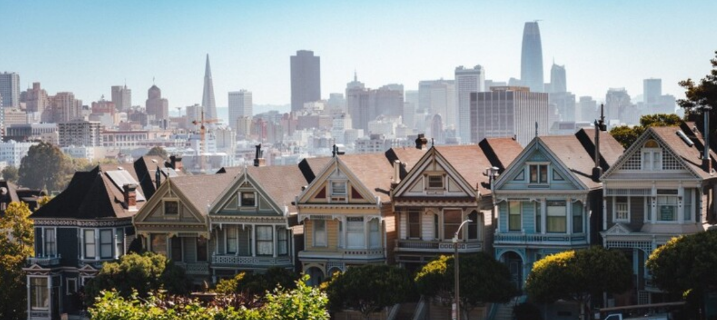



El California Housing Dataset es uno de los más conocidos en la literatura. Este dataset es un conjunto de datos de regresión que recoge información socioeconómica y geográfica de distritos de California a partir del censo de 1990, con el objetivo de predecir el precio medio de la vivienda. Contiene unas 20.000 observaciones y 8 variables numéricas como el ingreso medio, la edad de las viviendas, la población y la localización.

Para más información: https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset

<br>

## Dataset

### Cargar de datos

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True).frame
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### Leer los datos

Lo siguiente que deberíamos hacer para poder hacer un modelo sería investigar sobre los datos, saber qué significa cada variable, en qué unidades se mide, qué valores debería tener... Por ejemplo:

* **MedHouseVal**: Es la variable que mide el precio de una casa, así que va a ser nuestro target. Nos debería llamar la atención que tenga valores del orden de unidades ("¿qué quiere decir que una casa valga 4.526?"). Si leemos la documentación vemos que se mide en unidades de 100.000 dollares así que 4.526 quiere decir 452.600 dollares

<br>

### Datos erroneos

De las primeras cosa que tenemos que ver una vez que empezamos a trabajar con un dataset es ver si tiene datos erroneos (Recordemos que este dataset es lo que va a hacer que nuestra IA aprenda). En nuestro caso para hacer el ejercicio más realista, como el dataset está bastante limpio vamos a añadir algún error aposta para ver cómo corregirlo

In [ ]:
import random
random.seed(0)

# Añadimos 100 valores vacíos
for _ in range(100):
    data.iloc[random.randint(0, len(data) - 1),random.randint(0, len(data.columns) - 1)] = None

# Añadimos 5 datos duplicados
for _ in range(5):
    data.loc[random.randint(0, len(data))] = data.loc[random.randint(0, len(data))]

<br>

### Estadísticos generales

Lo primero es ver la distribución general de los datos. Esto nos ayuda a ver el rango en el que se distribuyen las variables, para ver si tiene sentido la distribución que siguen.

In [ ]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20631.000000,20620.000000,20627.000000,20629.000000,20632.000000,20630.000000,20634.000000,20632.000000,20625.000000
mean,3.870392,28.644568,5.428741,1.096730,1425.469271,3.070737,35.631586,-119.569325,2.068550
std,1.899074,12.587414,2.474958,0.474034,1132.386444,10.388549,2.135974,2.003643,1.153722
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563100,18.000000,4.439812,1.006116,787.000000,2.429994,33.930000,-121.800000,1.196000
50%,3.534900,29.000000,5.228228,1.048780,1166.000000,2.818016,34.260000,-118.490000,1.797000
75%,4.743400,37.000000,6.052257,1.099573,1725.000000,3.282267,37.710000,-118.010000,2.647000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<br>

### Valores nulos

Vemos que hay valores nulos. Los valores nulos no nos sirven para entrenar por ello hay que corregirlos. Para ello hay 2 opciones eliminarlos o imputarlos

In [ ]:
print(data.isnull().sum())

MedInc          9
HouseAge       20
AveRooms       13
AveBedrms      11
Population      8
AveOccup       10
Latitude        6
Longitude       8
MedHouseVal    15
dtype: int64


**Target column**: El target es una variable que rara vez se imputa, ya que al ser el varlo que queremos predecir, es mejor no modificarlo. Lo que vamos a hacer es hacer drop de las filas que tienen el target vacío

In [ ]:
data = data.dropna(subset=['MedHouseVal'])

In [ ]:
print(data.isnull().sum())

MedInc          9
HouseAge       20
AveRooms       13
AveBedrms      10
Population      8
AveOccup       10
Latitude        6
Longitude       8
MedHouseVal     0
dtype: int64


**Features**: El número de features es relativamente elevado, en muchas features, la mejor opción es imputar los valores manualmente. Vamos a imputar usando la media de cada columna

In [ ]:
for col in data.columns:
    data.loc[:, col] = data[col].fillna(data[col].mean())

In [ ]:
print(data.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


<br>

### Valores duplicados

Los valores duplicados deberíamos eliminarlos ya que añaden ruido al modelo (una fila duplicada hace que esa fila tenga "más peso" a la hora de entrenar el modelo que las demás)

In [ ]:
print(data.duplicated().sum())

5


In [ ]:
data = data.drop_duplicates()

In [ ]:
print(data.duplicated().sum())

0


<br>

### Outliers

Hay veces que los valores erroneos no aparecen como valores null, sino como outliers (valores muy distintos a la distribución general). A diferencia de los valores nulos, estos sí que puede que sean correctos, por ello es imporatante entenderlos antes de borrarlos directamente. Sea como fuere pueden afectar negativamente al proceso de entrenamiento y por tanto puede que sea necesario eliminarlos

**Distancia intercuantil**

In [ ]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outliers = (data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))
print(outliers.sum())

MedInc          679
HouseAge          0
AveRooms        511
AveBedrms      1424
Population     1198
AveOccup        712
Latitude          0
Longitude         0
MedHouseVal    1070
dtype: int64


**Valores anómalos**

In [ ]:
outliers =  (data < 0) | (data > data.mean(axis=0)*100)
print(outliers.sum())

MedInc             0
HouseAge           0
AveRooms           0
AveBedrms          0
Population         0
AveOccup           3
Latitude           0
Longitude      20620
MedHouseVal        0
dtype: int64


Vemos que hay outliers estadísticos pero tienen sentido que existan dentro del tipo de datos que estamos tranajando. Parece que no hay valores anómalos

<br>

---

## Preparación

### Feature selection

Lo primero de todo es ver qué variables con "predictoras" para el target. Solamente nos interesan aquellas que puedan contener información

In [ ]:
X=data[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']]
y=data['MedHouseVal']

> **Nota**: Podría considerarse latitud y longitud como variables predictoras?? La respuesta es sí, piensa por qué y cómo

<br>

### Train test split

Separamos en train y test para hacer el entrenamiento del modelo

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<br>

### Preprocesamiento

Podríamos hacer diferentes tipos de preprocesamiento. En este caso como hemos visto que la distribución tiene outliers estadísticos es conveniente usar un escalador que ayude a reducirlo

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

> **NOTA**: Generalmente es conveniente aplicar escaladores y/o transformaciones para cada columna ad hoc

---

## Entrenamiento

### Modelo

**ElasticNet**: Más adelante veremos más modelos, pero de momento vamos a seguir trabajando con la regresión lineal. ElasticNet es un tipo de regresión lineal que permite 2 parámetros para configurarles

In [ ]:
from sklearn.linear_model import ElasticNet

# Definir modelo
elastic = ElasticNet(max_iter=10000)

<br>

### Búsqueda de hiperparámetros

Además de elegir un modelo, cuando el modelo admite parámetros podemos probar diferentes configuraciones de modelos para ver qué configuración da mejores resultados

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV


# Grid de hiperparámetros
param_grid = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10], # fuerza de regularización
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]  # mezcla L1/L2
}

# GridSearch
grid = GridSearchCV(elastic, param_grid, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

# Mejor modelo
best_elastic = grid.best_estimator_
print("Mejores hiperparámetros:", grid.best_params_)


Mejores hiperparámetros: {'alpha': 0.001, 'l1_ratio': 1.0}


<br>

### Predicción

In [ ]:
X_test_scaled = scaler.transform(X_test)
y_pred = best_elastic.predict(X_test_scaled)

##

### Evaluación

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 0.6259540352779752
R2: 0.5303830156897381


<br>

# Conclusiones

* Hemos analizado California House Prize dataset. Es un dataset de precios de inmuebles que parece estar muy limpio (valores coherentes, sin valores nulos, erroneos ni duplicados), con lo cual lo hace óptimo para entrenar un modelo de ML

* Hemos conseguido entrenar un modelo lineal (ElasticNet) con un valor de R2 de 0.53. Esto nos da a entender que el precio de un inmueble es parcialmente predecible con las variables que hemos usado para entrenar el modelo lineal. Vemos que el modelo tiene un error cuadrático medio de 0.63 (o sea que las predicciones que hacemos son +-60.000 dollarea de precisas)

* Los motivos por los que el modelo puede no estar siendo más precisos son 2: Por un lado existen más variables que no estamos teniendo en cuenta (criminalidad del barrio, estado del inmueble,...) y por otro lado, puede que un modelo lineal no sea el mejor.